Initialization

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
df = pd.read_csv('C:/Users/josep/OneDrive/Desktop/Excel Studies/datasets to clean/ai_worker_burnout_attrition_2026.csv')
df

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise (5000+),Hybrid,36,47,...,7,6.9,69,Integrating,2.6,74,63,3.1,High,Medium
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small (50-200),Hybrid,22,199,...,1,1.2,7,Integrating,6.9,39,25,3.5,Low,Low
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid (200-1000),Hybrid,48,120,...,3,6.8,73,Optimizing,4.0,44,65,2.9,High,High
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup (<50),Fully Remote,41,208,...,6,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

In [125]:
df.isna().sum()

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
df['no_of_employees'] = df['company_size'].str.extract(r'(\d+)')
df['company_size'] = df['company_size'].str.split(' ').str[0]
df

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk,no_of_employees
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large,Fully Remote,8,184,...,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium,1000
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large,Hybrid,42,51,...,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium,1000
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup,Hybrid,37,185,...,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium,50
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid,Fully Remote,8,131,...,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium,200
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small,Fully Remote,21,99,...,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise,Hybrid,36,47,...,6.9,69,Integrating,2.6,74,63,3.1,High,Medium,5000
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small,Hybrid,22,199,...,1.2,7,Integrating,6.9,39,25,3.5,Low,Low,50
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid,Hybrid,48,120,...,6.8,73,Optimizing,4.0,44,65,2.9,High,High,200
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup,Fully Remote,41,208,...,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium,50


EDA Section

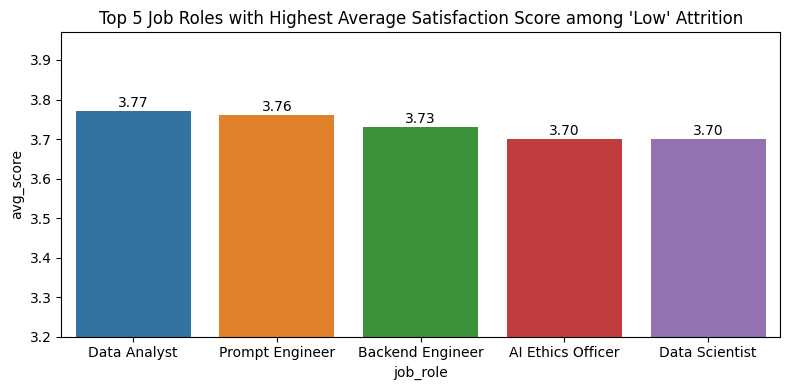

In [128]:
#1: Finding top 5 job roles with highest satisfaction score among 'Low' attrition risked employees
temp_df = df.copy()
temp_df = temp_df[temp_df['attrition_risk'] == 'Low'] 
temp_df = (
    temp_df.groupby('job_role')['job_satisfaction_1_5'].mean()
    .nlargest(5)
    .reset_index(name='avg_score')
)
temp_df['avg_score'] = round(temp_df['avg_score'], 2)
y_max = temp_df['avg_score'].max()
y_min = temp_df['avg_score'].min()
offset = (y_max - y_min) * 0.05

plt.figure(figsize=(8,4))
ax = sns.barplot(data=temp_df, x='job_role', y='avg_score', hue='job_role')
plt.title("Top 5 Job Roles with Highest Average Satisfaction Score among 'Low' Attrition")

for p in ax.patches:
    height = p.get_height()  
    ax.text(
        p.get_x() + p.get_width()/2,  
        height + offset,                  
        f'{height:.2f}',             
        ha='center',                  
        va='bottom',                  
    )

plt.ylim(y_min-0.5, y_max+0.2)
plt.tight_layout()
plt.show()



In [129]:
#2: Finding average AI assistance hours per day, percemtage for work to be replaced by AI, AI upskill weekly hours for all company sizes
temp_df = df.copy()
temp_df = (
    temp_df.groupby('company_size')[['hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs']]
    .mean().round(2).reset_index()
    .sort_values(by='ai_replaces_my_tasks_pct',ascending=False)
)
temp_df

,company_size,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs
4,Startup,4.23,42.01,4.84
0,Enterprise,4.17,41.34,5.16
3,Small,4.18,41.27,4.77
2,Mid,4.30,41.15,4.92
1,Large,4.29,40.41,5.24


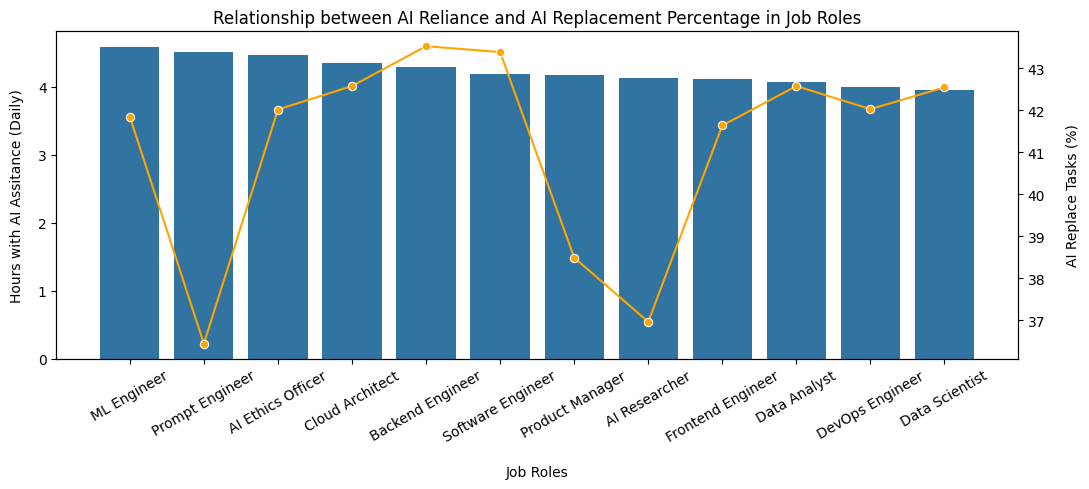

,job_role,ai_tools_used_per_day,ai_replaces_my_tasks_pct,hours_with_ai_assistance_daily
8,ML Engineer,4.21,41.85,4.59
10,Prompt Engineer,4.30,36.44,4.52
0,AI Ethics Officer,4.05,42.02,4.47
3,Cloud Architect,3.95,42.58,4.35
2,Backend Engineer,4.08,43.53,4.30
11,Software Engineer,3.89,43.39,4.19
9,Product Manager,3.99,38.49,4.17
1,AI Researcher,3.98,36.96,4.13
7,Frontend Engineer,4.05,41.64,4.12
4,Data Analyst,4.10,42.58,4.08


In [130]:
#3: Finding jobs that require the use of ai tools more per day and hours, and the percentage to replace labor with AI
temp_df = df.copy()
temp_df = (
    temp_df.groupby('job_role')[['ai_tools_used_per_day', 'ai_replaces_my_tasks_pct', 'hours_with_ai_assistance_daily']]
    .mean().round(2).reset_index()
    .sort_values(by='hours_with_ai_assistance_daily',ascending=False)
)

plt.figure(figsize=(11,5))
plt.title('Relationship between AI Reliance and AI Replacement Percentage in Job Roles')
ax1 = sns.barplot(data=temp_df, x='job_role', y='hours_with_ai_assistance_daily')
ax1.set_ylabel('Hours with AI Assitance (Daily)', labelpad=10)
plt.xticks(rotation=30)

ax2 = ax1.twinx()
sns.lineplot(data=temp_df, x='job_role', y='ai_replaces_my_tasks_pct', marker='o', color='orange', ax=ax2)
ax2.set_ylabel('AI Replace Tasks (%)', labelpad=15)
ax1.set_xlabel('Job Roles', labelpad=15)
plt.tight_layout()
plt.show()

temp_df


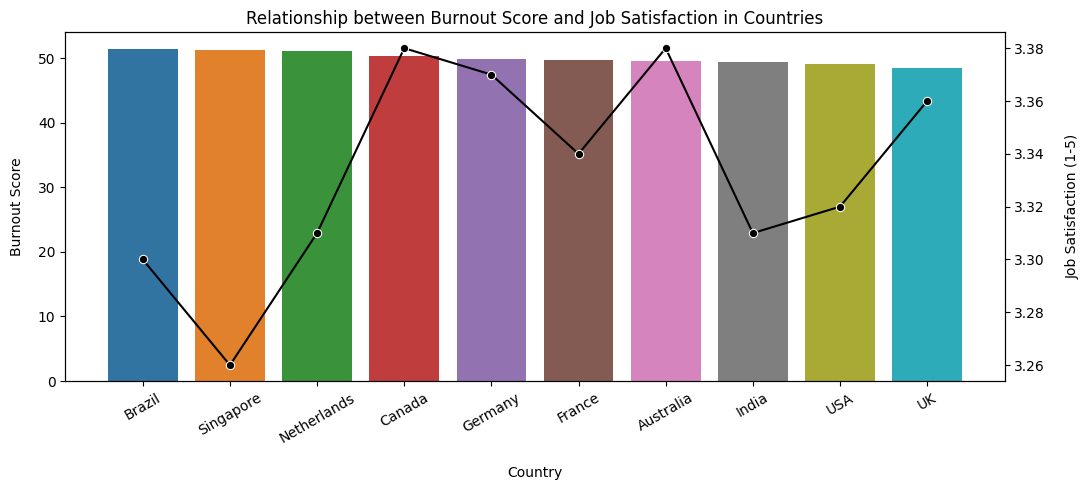

In [131]:
#4: Finding top countries with highest burnout rate and their average job satisfaction score respectively
temp_df = df.copy()
temp_df = (
    temp_df.groupby('country')[['burnout_score','job_satisfaction_1_5']]
    .mean().round(2).reset_index()
    .sort_values(by='burnout_score', ascending=False)
)

plt.figure(figsize=(11,5))
plt.title('Relationship between Burnout Score and Job Satisfaction in Countries')
ax1 = sns.barplot(data=temp_df, x='country', y='burnout_score', hue='country')
ax1.set_ylabel('Burnout Score', labelpad=10)
plt.xticks(rotation=30)

ax2 = ax1.twinx()
sns.lineplot(data=temp_df, x='country', y='job_satisfaction_1_5', marker='o', color='black', ax=ax2)
ax2.set_ylabel('Job Satisfaction (1-5)', labelpad=15)
ax1.set_xlabel('Country', labelpad=15)
plt.tight_layout()
plt.show()


In [132]:
#5: Finding top industries with highest percentage for AI replacements among 'High' feared employees
temp_df = df.copy()
temp_df = temp_df[temp_df['fear_of_ai_replacement'] == 'High']
temp_df = (
    temp_df.groupby('industry')['ai_replaces_my_tasks_pct']
    .mean().nlargest(5).round(2).reset_index()
    .sort_values(by='ai_replaces_my_tasks_pct', ascending=False)
)
temp_df

,industry,ai_replaces_my_tasks_pct
0,Cybersecurity,47.63
1,SaaS,47.38
2,Consulting,46.32
3,Automotive,45.15
4,E-commerce,43.00
